## Monitoring

Simula monitoreo de producción usando data/raw/test.csv

Cubre:

- Target drift: default rate mensual vs. baseline de train
- PSI por feature
- Score drift: distribución de probabilidades
- Calibration Drift

In [118]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import json
import yaml
import dagshub

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    auc,
    roc_auc_score,
    classification_report,
    roc_curve,
    precision_recall_curve,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from pathlib import Path
import sys
import optuna
from optuna.samplers import TPESampler
import shap

#### Debido a la ausencia de datos de producción/OOT, el Target Drift se evalúa utilizando el Test.csv como proxy de población futura.

### Target Drift

In [40]:
predictions_test_oot = pd.read_parquet('../artifacts/predictions/test_oot_predictions.parquet')
y_train = pd.read_parquet('../data/splits/y_train.parquet')

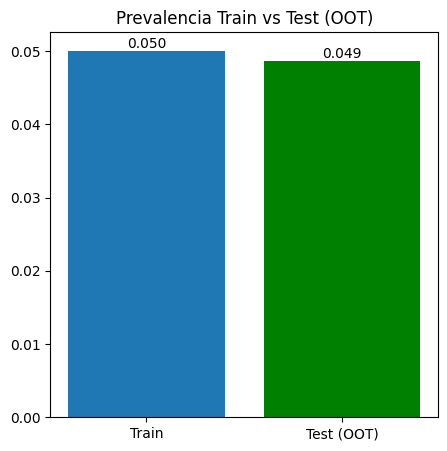

In [127]:
fig, ax = plt.subplots(1, 1, figsize = (5,5))
bar_1 = ax.bar(
    x= ['Train'],
    height= y_train.squeeze().mean() 
)
ax.bar_label(bar_1, fmt= '%.3f')
bar_2 = ax.bar(
    x= ['Test (OOT)'],
    height= predictions_test_oot['y_true'].mean(),
    color = 'green'
)
ax.bar_label(bar_2, fmt= '%.3f')
ax.set_title('Prevalencia Train vs Test (OOT)')
fig.savefig('../reports/figures/monitoring/target_drift.png')
plt.show()

In [42]:
print('=== Reporte de Target Drift ===')
print(f'''
Default Rate - Train:      {round(y_train.squeeze().mean(), 3)}
Default Rate - Test/OOT:   {round(predictions_test_oot['y_true'].mean(), 3)}
      
Se observa que la prevalencia entre Train y Target es casi la misma, por lo cual 
se puede intuir que no se ha encontrado Target Drift''')

=== Reporte de Target Drift ===

Default Rate - Train:      0.05
Default Rate - Test/OOT:   0.049

Se observa que la prevalencia entre Train y Target es casi la misma, por lo cual 
se puede intuir que no se ha encontrado Target Drift


### Performance Drift (AUC)
Baseline (Train) vs Test (en esta simulación es como el OOT)

In [34]:
## TRAIN
with open('../artifacts/model/metrics_train.json', 'r') as f:
    metrics_train = json.load(f)

auc_train = metrics_train['auc']

## Test/OOT
with open('../artifacts/metrics/metrics_test_oot.json', 'r') as f:
    metrics_test_oot = json.load(f)

auc_test_oot = metrics_test_oot['auc']

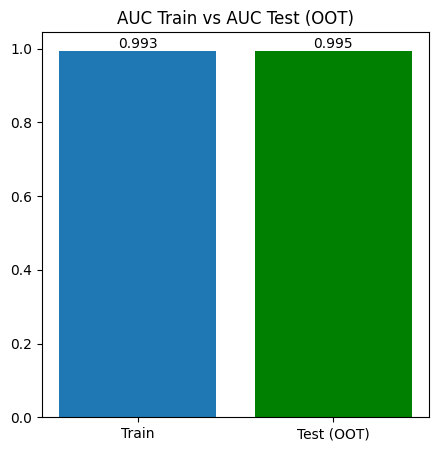

In [126]:
fig, ax = plt.subplots(1, 1, figsize = (5,5))
bar_1 = ax.bar(
    x= ['Train'],
    height= auc_train
)
ax.bar_label(bar_1, fmt= '%.3f')
bar_2 = ax.bar(
    x= ['Test (OOT)'],
    height= auc_test_oot,
    color = 'green'
)
ax.bar_label(bar_2, fmt= '%.3f')
ax.set_title('AUC Train vs AUC Test (OOT)')
fig.savefig('../reports/figures/monitoring/performance_drift.png')
plt.show()

In [38]:
print('=== Reporte de Performance Drift ===')
print(f'''
AUC Train       : {round(auc_train, 3)}
AUC Test/OOT    : {round(auc_test_oot, 3)}

Prácticamente mantiene el performance considerando el baseline de Train.
Por lo que se intuye que NO tenemos Concept Drift
''')

=== Reporte de Performance Drift ===

AUC Train       : 0.993
AUC Test/OOT    : 0.995

Prácticamente mantiene el performance considerando el baseline de Train.
Por lo que se intuye que NO tenemos Concept Drift



### Score Drift

In [43]:
# Train
predictions_train = pd.read_parquet('../artifacts/predictions/train_predictions.parquet')
score_train = predictions_train['y_score']

# Test/OOT
predictions_test_oot = pd.read_parquet('../artifacts/predictions/test_oot_predictions.parquet')
score_test_oot = predictions_test_oot['y_score']

In [48]:
score_train.mean()

np.float64(0.07795715625823708)

In [49]:
score_test_oot.mean()

np.float64(0.07519565155254802)

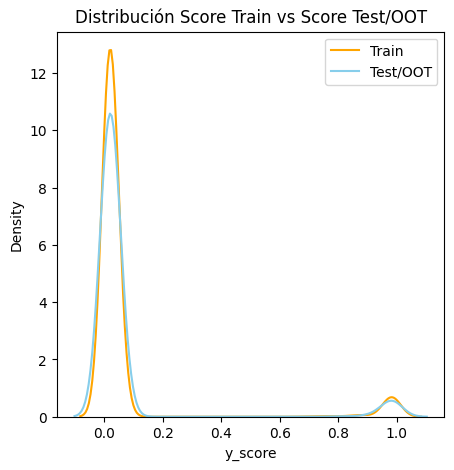

In [125]:
fig, ax = plt.subplots(1,1, figsize = (5,5))

sns.kdeplot(
    score_train,
    label='Train',
    color= 'orange'
)

sns.kdeplot(
    score_test_oot,
    label='Test/OOT',
    color= 'skyblue'
)

ax.set_title('Distribución Score Train vs Score Test/OOT')
ax.legend()
fig.savefig('../reports/figures/monitoring/score_drift.png')
plt.show()

### PSI de los Features

In [55]:
class Drift:
    def __init__(self):
        pass

    def _pre_bins(self, bins: list):
        """Pre procesa los bins numéricos incluyendo los rangos -np.inf y np.inf"""
        bins[-1] = np.inf
        bins.insert(0, -np.inf)
        return bins

    
    def woe(self, features_numericas: list, features_categoricas: list, dataset: pd.DataFrame, target: pd.Series):
        """Retorna una lista de Dataframes para analizar la monotonicidad de cada feature"""
        lista_df_numericos = []
        lista_df_categoricas = []
        dataset_merge = dataset.copy()
        dataset_merge["target"] = target
        epsilon = 1e-6
        list_labels_num = []
        list_cortes_num = []
        list_intervalos_cat = []
        
        for i in features_numericas:
            cortes = pd.qcut(dataset_merge[i], q= 5, retbins=True, duplicates= "drop")[1].tolist()
            #intervalos = pd.qcut(dataset_merge[i], q= 5).cat.codes
            dataset_merge["bin"] = pd.qcut(dataset_merge[i], q= 5, duplicates= "drop")
            
            agg = dataset_merge.groupby(
                ["bin"], observed= False
            ).agg(
                total = ("target", "count"),
                eventos = ("target", "sum")
            )
            agg["no_eventos"] = agg["total"] - agg["eventos"]
            agg["event_rate"] = agg["eventos"] / agg["total"]
            agg["pct_obs"] = agg["total"] / agg["total"].sum()
            agg["dist_eventos"] = agg["eventos"] / agg["eventos"].sum()
            agg["dist_no_eventos"] = agg["no_eventos"] / agg["no_eventos"].sum()
            agg["woe"] = np.log(
                (agg["dist_no_eventos"] + epsilon)/(agg["dist_eventos"] + epsilon)
            )
            agg["iv"] = (agg["dist_no_eventos"] - agg["dist_eventos"]) * agg["woe"]

            agg = agg.reset_index()

            feature_num = pd.DataFrame({
                "feature": i,
                "bin": range(len(agg)),
                "intervalo": agg["bin"].astype("str"),
                "regla": cortes[1:],
                "n_observaciones": agg["total"],
                "pct_obs": agg["pct_obs"],
                "n_eventos": agg["eventos"],
                "n_no_eventos": agg["no_eventos"],
                "bad_rate": agg["event_rate"],
                "dist_eventos": agg["dist_eventos"],
                "dist_no_eventos": agg["dist_no_eventos"],
                "WOE":  agg["woe"],
                "IV": agg["iv"]
            })
            
            new_bins = self._pre_bins(bins = cortes[1:])
            lista_df_numericos.append(feature_num)
            list_labels_num.append(agg["bin"].astype("str"))
            list_cortes_num.append(new_bins)

        for i in features_categoricas:

            agg = dataset_merge.groupby(
                [i]
            ).agg(
                total = ("target", "count"),
                eventos = ("target", "sum")
            )

            agg["no_eventos"] = agg["total"] - agg["eventos"]
            agg["event_rate"] = agg["eventos"] / agg["total"]
            agg["dist_eventos"] = agg["eventos"] / agg["eventos"].sum()
            agg["dist_no_eventos"] = agg["no_eventos"] / agg["no_eventos"].sum()
            agg["woe"] = np.log(
                (agg["dist_no_eventos"] + epsilon)/(agg["dist_eventos"] + epsilon)
            )
            agg["iv"] = (agg["dist_no_eventos"] - agg["dist_eventos"]) * agg["woe"]
            agg["pct_obs"] = agg["total"] / agg["total"].sum()

            agg = agg.reset_index()

            feature_cat = pd.DataFrame({
                "feature": i,
                "bin": range(len(agg)),
                "intervalo": agg[i].astype("str"),
                "n_observaciones": agg["total"],
                "pct_obs": agg["pct_obs"],
                "n_eventos": agg["eventos"],
                "n_no_eventos": agg["no_eventos"],
                "bad_rate": agg["event_rate"],
                "dist_eventos": agg["dist_eventos"],
                "dist_no_eventos": agg["dist_no_eventos"],
                "WOE":  agg["woe"],
                "IV": agg["iv"]
            })
            lista_df_categoricas.append(feature_cat)
            list_intervalos_cat.append(agg[i].astype("str"))

        print("Lista de Dataframes creados exitosamente...")
        return lista_df_numericos, lista_df_categoricas, list_labels_num, list_cortes_num, list_intervalos_cat
    

    def woe_comparacion(self, features_numericas: list, features_categoricas: list, dataset: pd.DataFrame, target: pd.Series, labels_num = [], bins_num = [], intervalos_cat = []):
        """Retorna una lista de Dataframes para analizar la monotonicidad de cada feature"""
        lista_df_numericos = []
        lista_df_categoricas = []
        dataset_merge = dataset.copy()
        dataset_merge["target"] = target
        epsilon = 1e-6
        
        for x, i in enumerate(features_numericas):
            cortes = bins_num[x]
            #cortes = cortes[1:]
            #print(cortes)
            #print(type(cortes))
            dataset_merge["bin"] = pd.cut(
                dataset_merge[i],
                labels= labels_num[x],
                bins= bins_num[x]
            )
            #print(f"Tamaño dataset: {len(dataset_merge)}")
        
            agg = dataset_merge.groupby(
                ["bin"], observed= False
            ).agg(
                total = ("target", "count"),
                eventos = ("target", "sum")
            )
            #print(f"Tamaño agg: {len(agg)}")
            agg["no_eventos"] = agg["total"] - agg["eventos"]
            agg["event_rate"] = agg["eventos"] / agg["total"]
            agg["pct_obs"] = agg["total"] / agg["total"].sum()
            agg["dist_eventos"] = agg["eventos"] / agg["eventos"].sum()
            agg["dist_no_eventos"] = agg["no_eventos"] / agg["no_eventos"].sum()
            agg["woe"] = np.log(
                (agg["dist_no_eventos"] + epsilon)/(agg["dist_eventos"] + epsilon)
            )
            agg["iv"] = (agg["dist_no_eventos"] - agg["dist_eventos"]) * agg["woe"]

            agg = agg.reset_index()
            #print(len(agg))

            feature_num = pd.DataFrame({
                "feature": i,
                "bin": range(len(agg)),
                "intervalo": agg["bin"].astype("str"),
                "regla": cortes[1:],
                "n_observaciones": agg["total"],
                "pct_obs": agg["pct_obs"],
                "n_eventos": agg["eventos"],
                "n_no_eventos": agg["no_eventos"],
                "bad_rate": agg["event_rate"],
                "dist_eventos": agg["dist_eventos"],
                "dist_no_eventos": agg["dist_no_eventos"],
                "WOE":  agg["woe"],
                "IV": agg["iv"]
            })
            
            lista_df_numericos.append(feature_num)

        for x, i in enumerate(features_categoricas):
            cats = intervalos_cat[x]
            dataset_merge[i] = dataset_merge[i].where(
                dataset_merge[i].isin(cats),
                "OTHER"
            )

            agg = dataset_merge.groupby(
                [i]
            ).agg(
                total = ("target", "count"),
                eventos = ("target", "sum")
            )
            #print(agg)
            agg = agg.reindex(list(cats) + ["OTHER"], fill_value= 0)
            #print(f'========== DESPUÉS =========')
            #print(agg)
            
            agg["no_eventos"] = agg["total"] - agg["eventos"]
            agg["event_rate"] = agg["eventos"] / agg["total"]
            agg["dist_eventos"] = agg["eventos"] / agg["eventos"].sum()
            agg["dist_no_eventos"] = agg["no_eventos"] / agg["no_eventos"].sum()
            agg["woe"] = np.log(
                (agg["dist_no_eventos"] + epsilon)/(agg["dist_eventos"] + epsilon)
            )
            agg["iv"] = (agg["dist_no_eventos"] - agg["dist_eventos"]) * agg["woe"]
            agg["pct_obs"] = agg["total"] / agg["total"].sum()

            agg = agg.reset_index()

            feature_cat = pd.DataFrame({
                "feature": i,
                "bin": range(len(agg)),
                "intervalo": agg[i].astype("str"),
                "n_observaciones": agg["total"],
                "pct_obs": agg["pct_obs"],
                "n_eventos": agg["eventos"],
                "n_no_eventos": agg["no_eventos"],
                "bad_rate": agg["event_rate"],
                "dist_eventos": agg["dist_eventos"],
                "dist_no_eventos": agg["dist_no_eventos"],
                "WOE":  agg["woe"],
                "IV": agg["iv"]
            })
            lista_df_categoricas.append(feature_cat)

        print("Lista de Dataframes creados exitosamente...")
        return lista_df_numericos, lista_df_categoricas
    
    
    def psi(self, features_numericas: list, features_categoricas: list, dataset_base: pd.DataFrame, target: pd.Series, dataset_compare: pd.DataFrame, target_compare = pd.Series):
        """Calcula directamente el PSI, para ello calcula el WOE y PSI previamente"""
        list_feats_numericas_base, list_feats_categoricas_base, labels_num, bins_num, interv_cat = self.woe(
            dataset= dataset_base,
            features_categoricas= features_categoricas,
            features_numericas= features_numericas,
            target= target
        )
        #display(interv_cat)

        list_feats_num_comp, list_feats_cat_comp = self.woe_comparacion(
            features_numericas = features_numericas, 
            features_categoricas = features_categoricas,
            dataset = dataset_compare,
            target = target_compare,
            labels_num = labels_num,
            bins_num = bins_num, 
            intervalos_cat = interv_cat)
        
        #print(list_feats_cat_comp[0]['intervalo'])
        
        eps = 1e-6

        list_num_psi = []
        list_feat_num = []
        list_psi_num = []
        list_iv_base_num = []
        list_iv_comp_num = []

        print("Iniciando el cruce entre baseline y comparación para numéricas...")
        for base, comp in zip(list_feats_numericas_base, list_feats_num_comp):
            df_tmp = comp.merge(base, how = "left", on = ["feature" , "bin"], suffixes = ("", "_base"))
            feat_num = ["feature", "bin", "regla", "pct_obs", "pct_obs_base", "WOE", "WOE_base", "IV", "IV_base"]
            df_tmp = df_tmp[feat_num]
            df_tmp["psi"] = ( df_tmp["pct_obs_base"].clip(eps, 1) - df_tmp["pct_obs"].clip(eps, 1) ) * np.log( (df_tmp["pct_obs_base"].clip(eps, 1)) / (df_tmp["pct_obs"].clip(eps, 1))  )
            
            feature = df_tmp["feature"].unique()[0]
            psi = df_tmp["psi"].sum()
            iv_base = df_tmp["IV_base"].sum()
            iv_comp = df_tmp["IV"].sum()

            list_num_psi.append(df_tmp)

            list_feat_num.append(feature)
            list_psi_num.append(psi)
            list_iv_base_num.append(iv_base)
            list_iv_comp_num.append(iv_comp)

        print("Iniciando el cruce entre baseline y comparación para categóricas...")
        for base, comp in zip(list_feats_categoricas_base, list_feats_cat_comp):
            df_tmp = comp.merge(base, how = "left", on = ["feature" , "intervalo"], suffixes = ("", "_base"))
            feat_num = ["feature", "bin", "bin_base", "intervalo", "pct_obs", "pct_obs_base", "WOE", "WOE_base", "IV", "IV_base"]
            df_tmp = df_tmp[feat_num]
            df_tmp["psi"] = ( df_tmp["pct_obs_base"].clip(eps, 1) - df_tmp["pct_obs"].clip(eps, 1) ) * np.log( (df_tmp["pct_obs_base"].clip(eps, 1)) / (df_tmp["pct_obs"].clip(eps, 1))  )
            
            feature = df_tmp["feature"].unique()[0]
            psi = df_tmp["psi"].sum()
            iv_base = df_tmp["IV_base"].sum()
            iv_comp = df_tmp["IV"].sum()

            list_num_psi.append(df_tmp)

            list_feat_num.append(feature)
            list_psi_num.append(psi)
            list_iv_base_num.append(iv_base)
            list_iv_comp_num.append(iv_comp)

        print("Creando el resumen...")

        df_overall = pd.DataFrame({
            "Feature": list_feat_num,
            "PSI": list_psi_num,
            "IV Base": list_iv_base_num,
            "IV Comparative": list_iv_comp_num
        }).sort_values(by= "PSI", ascending= False)

        return df_overall, list_num_psi


In [58]:
with open('../params.yaml', 'r') as params:
    params = yaml.safe_load(params)

FEATURES = params['features']
NUMERIC = FEATURES['numeric']
CATEGORICAL = FEATURES['categorical']
TARGET = FEATURES['target']

In [61]:
## Aplicar Transformación (Ya que no se ha guardado los .parquet ya aplicados el preprocessor)
#preprocessor = joblib.load('../artifacts/preprocessors/preprocessor.pkl')

## Datasets Train y Test/OOT
X_train_woe = pd.read_parquet('../data/features/X_train_woe.parquet')
y_train_woe = pd.read_parquet('../data/features/y_train_woe.parquet')

X_test_oot_woe = pd.read_parquet('../data/features/X_test_oot_woe.parquet')
y_test_oot_woe = pd.read_parquet('../data/features/y_test_oot_woe.parquet')

#X_train_transformed = preprocessor.transform(X_train_woe)
#X_test_oot_transformed = preprocessor.transform(X_test_oot_woe)


In [ ]:
drop_numeric = ['no_of_days_employed', 'credit_limit_used(%)', 'credit_score']
[NUMERIC.remove(d) for d in drop_numeric]

In [75]:
NUMERIC_WOE = ['no_of_days_employed_woe', 'credit_limit_used(%)_woe', 'credit_score_woe']
NUMERIC = NUMERIC + NUMERIC_WOE

In [77]:
# Aqui solo compararé el baseline vs future considerando las features antes de transformar para efectos prácticos, pero es recomendable también comparar con los features finales luego de la transformación
drift = Drift()
df_overall, list_num_psi = drift.psi(
features_numericas = NUMERIC,
features_categoricas = CATEGORICAL,
dataset_base = X_train_woe,
target = y_train_woe.squeeze(),
dataset_compare = X_test_oot_woe,
target_compare = y_test_oot_woe.squeeze())


Lista de Dataframes creados exitosamente...
Lista de Dataframes creados exitosamente...
Iniciando el cruce entre baseline y comparación para numéricas...
Iniciando el cruce entre baseline y comparación para categóricas...
Creando el resumen...


In [123]:
df_overall[['Feature', 'PSI']]

# Guardar tabla
df_overall[['Feature', 'PSI']].to_parquet('../artifacts/monitoring/features_psi.parquet')

In [86]:
print('=== Reporte PSI ===')
print(f'''
Se observa que el feature:
    - "no_of_days_employed_woe"
tiene un PSI bastante alto, por lo tanto hay un Covariate Drift o Data en esa feature,
el share data drift de las features analizadas sería de 6.7%

Como el AUC está estable y aún falta ver la calibración, se recomienda por ahora:      
    - Acción Inmediata: Monitorear''')

=== Reporte PSI ===

Se observa que el feature:
    - "no_of_days_employed_woe"
tiene un PSI bastante alto, por lo tanto hay un Covariate Drift o Data en esa feature,
el share data drift de las features analizadas sería de 6.7%

Como el AUC está estable y aún falta ver la calibración, se recomienda por ahora:      
    - Acción Inmediata: Monitorear


### Calibration Drift

In [111]:
predictions_train['bins_y_score'] = pd.cut(
    predictions_train['y_score'],
    bins= 8,
)

_, bins = pd.cut(
    predictions_train['y_score'],
    bins= 8,
    retbins= True
)

agg_predictions_train = (
    predictions_train.groupby(
        ['bins_y_score']
    ).agg(
        y_true_mean = ('y_true', 'mean'),
        score_mean = ('y_score', 'mean'),
        n_obs = ('y_score', 'count')
    )
).reset_index(level= 0, drop= False)
agg_predictions_train

,bins_y_score,y_true_mean,score_mean,n_obs
0,"(-0.000868, 0.125]",0.000000,0.020761,34211
1,"(0.625, 0.75]",0.365385,0.719860,52
2,"(0.75, 0.875]",0.427481,0.831403,131
3,"(0.875, 1.0]",0.862426,0.977683,2028


In [113]:
predictions_test_oot['bins_y_score'] = pd.cut(
    predictions_test_oot['y_score'],
    bins= bins
)
agg_predictions_test_oot = (
    predictions_test_oot.groupby(
        ['bins_y_score']
    ).agg(
        y_true_mean = ('y_true', 'mean'),
        score_mean = ('y_score', 'mean'),
        n_obs = ('y_score', 'count')
    )
).reset_index(level= 0, drop= False)
agg_predictions_test_oot

,bins_y_score,y_true_mean,score_mean,n_obs
0,"(-0.000868, 0.125]",0.000000,0.020752,10731
1,"(0.75, 0.875]",0.588235,0.808814,17
2,"(0.875, 1.0]",0.857143,0.975422,630


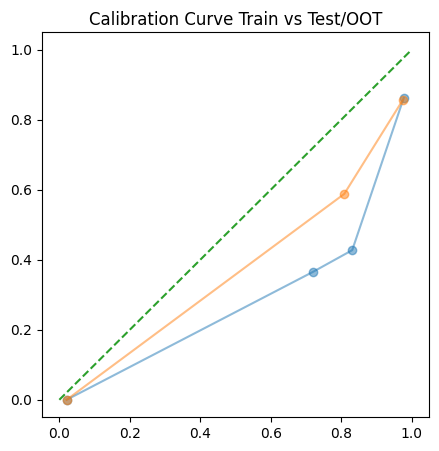

In [122]:
fig, ax = plt.subplots(1,1, figsize = (5,5))
ax.plot(
    agg_predictions_train['score_mean'],
    agg_predictions_train['y_true_mean'],
    label = ['Train'],
    alpha = 0.5,
    marker = 'o'
)

ax.plot(
    agg_predictions_test_oot['score_mean'],
    agg_predictions_test_oot['y_true_mean'],
    label = ['Test/OOT'],
    alpha = 0.5,
    marker = 'o'
)

ax.plot(
    [0,1],
    [0,1],
    '--'
)
ax.set_title('Calibration Curve Train vs Test/OOT')

fig.savefig('../reports/figures/monitoring/monitoring_calibration.png')

plt.show()

In [116]:
print('=== Reporte Calibration Drift ===')
print(f'''
Se observa que desde el Train existe un Overconfident ya que el modelo entrenado
sobre estima el riego y lo mismo sucede con Test/OOT.
Pero a nivel de variación se observa que no se visualiza un Calibration Drift significante.
      
Acción recomendada: Recalibración''')

=== Reporte Calibration Drift ===

Se observa que desde el Train existe un Overconfident ya que el modelo entrenado
sobre estima el riego y lo mismo sucede con Test/OOT.
Pero a nivel de variación se observa que no se visualiza un Calibration Drift significante.

Acción recomendada: Recalibración


### Integrar con MLFLOW

In [ ]:
dagshub.init(repo_owner='davidrodriguez2712', repo_name='proyecto-3-riesgo-crediticio', mlflow=True)

Accessing as davidrodriguez2712

Initialized MLflow to track repo "davidrodriguez2712/proyecto-3-riesgo-crediticio"

Repository davidrodriguez2712/proyecto-3-riesgo-crediticio initialized!

In [120]:
mlflow.set_tracking_uri('https://dagshub.com/davidrodriguez2712/proyecto-3-riesgo-crediticio.mlflow')
mlflow.set_experiment(experiment_name='Proyecto_3_riesgo_credito')

<Experiment: artifact_location='mlflow-artifacts:/a6c5ecb911f8453daf1b24b248c6b22c', creation_time=1777748161120, experiment_id='2', last_update_time=1777748161120, lifecycle_stage='active', name='Proyecto_3_riesgo_credito', tags={'mlflow.experimentKind': 'custom_model_development'}, trace_location=None, workspace='default'>

In [129]:
with mlflow.start_run(run_name='05_monitoring') as run:
    mlflow.log_artifact('../reports/figures/monitoring/performance_drift.png')
    mlflow.log_artifact('../reports/figures/monitoring/monitoring_calibration.png')
    mlflow.log_artifact('../reports/figures/monitoring/score_drift.png')
    mlflow.log_artifact('../reports/figures/monitoring/target_drift.png')
    mlflow.log_artifact('../artifacts/monitoring/features_psi.parquet')

🏃 View run 05_monitoring at: https://dagshub.com/davidrodriguez2712/proyecto-3-riesgo-crediticio.mlflow/#/experiments/2/runs/48d2d1815cb344da83e862cc85541875
🧪 View experiment at: https://dagshub.com/davidrodriguez2712/proyecto-3-riesgo-crediticio.mlflow/#/experiments/2
